<a href="https://colab.research.google.com/github/NeuralDataMind/JAX/blob/main/JAX_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [48]:
N_SAMPLES = 200
LAYERS = [1, 10, 10, 10, 1]
LEARNING_RATE = 0.1
N_EPOCHS = 30_000

In [49]:
key = jax.random.PRNGKey(42) # seed

In [50]:
key, xkey, ynoisekey = jax.random.split(key, 3)

In [51]:
x_samples = jax.random.uniform(xkey,(N_SAMPLES, 1), minval = 0.0, maxval = 2 * jnp.pi)
y_samples = jnp.sin(x_samples) + jax.random.normal(ynoisekey, (N_SAMPLES, 1)) * 0.3

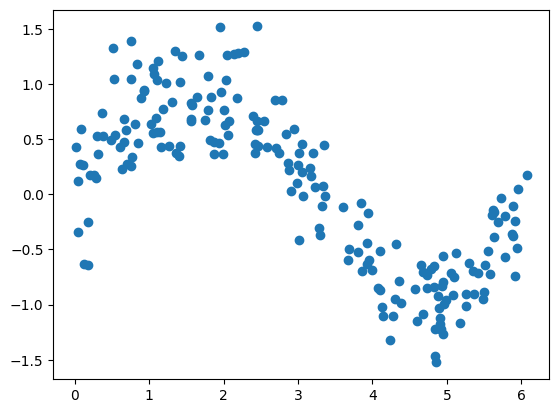

In [52]:
plt.scatter(x_samples, y_samples)

In [53]:
weight_matrices = []
bias_vectors = []
activation_functions = []

for(fan_in, fan_out) in zip(LAYERS[:-1], LAYERS[1:]):
    kernal_matrix_uniform_limit = jnp.sqrt(6/(fan_in + fan_out))

    key, wkey = jax.random.split(key)

    w = jax.random.uniform(
            wkey,
            (fan_in, fan_out),
            minval = - kernal_matrix_uniform_limit,
            maxval = + kernal_matrix_uniform_limit,
    )

    b = jnp.zeros(fan_out)

    weight_matrices.append(w)
    bias_vectors.append(b)
    activation_functions.append(jax.nn.sigmoid)

activation_functions[-1] = lambda x:x

In [54]:
def network_forward(x, weights, biases, activations):
    a = x
    for w, b, f in zip(
        weights,
        biases,
        activations,
    ):
        a = f(a @ w + b)
    return a

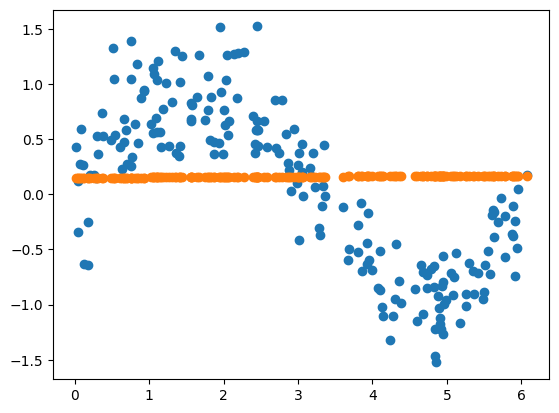

In [55]:
plt.scatter(x_samples, y_samples)
plt.scatter(x_samples, network_forward(x_samples, weight_matrices, bias_vectors, activation_functions))

In [56]:
def loss_forward(y_guess, y_ref):
    delta = y_guess - y_ref
    return 0.5 * jnp.mean(delta**2)

In [57]:
loss_forward(
    network_forward(
        x_samples,
        weight_matrices,
        bias_vectors,
        activation_functions),
        y_samples
)

Array(0.28443003, dtype=float32)

In [58]:
loss_and_grad_fun = jax.value_and_grad(
    lambda Ws, bs : loss_forward(
        network_forward(
            x_samples,
            Ws,
            bs,
            activation_functions,
        ),
        y_samples,
     ),
     argnums = (0, 1)
)

In [59]:
inital_loss, (initial_weight_gradient, initial_bias_gradient) = loss_and_grad_fun( weight_matrices, bias_vectors,)

In [60]:
inital_loss

Array(0.28443003, dtype=float32)

In [61]:
initial_weight_gradient

[Array([[ 0.00091228,  0.00015875, -0.01608167, -0.00049182, -0.00010407,
         -0.00800303, -0.00064232, -0.00237064, -0.00015847, -0.00090652]],      dtype=float32),
 Array([[-7.5154210e-05,  3.3338382e-04,  1.1344468e-04,  4.4245028e-04,
          3.4349973e-04, -4.9868046e-04, -3.8573131e-04,  1.5519082e-04,
          1.5846512e-04, -2.5762300e-04],
        [ 2.7194200e-04, -1.4746571e-03, -8.5741881e-04, -7.5509079e-04,
         -2.0462866e-03,  1.9731596e-03,  1.2543388e-03, -1.4676375e-03,
         -7.5843639e-04,  1.2185267e-03],
        [-2.3593273e-04,  1.1757943e-03,  5.7134731e-04,  9.8184322e-04,
          1.4650894e-03, -1.6467520e-03, -1.1430489e-03,  9.2344824e-04,
          5.8654213e-04, -9.4656425e-04],
        [ 2.6649362e-04, -1.4480358e-03, -8.4512029e-04, -7.3080882e-04,
         -2.0140202e-03,  1.9354583e-03,  1.2277546e-03, -1.4480668e-03,
         -7.4524898e-04,  1.1972011e-03],
        [-8.3567947e-04,  4.3046316e-03,  2.2567769e-03,  3.0362986e-03,
    

In [62]:
loss_and_grad_fun = jax.jit(loss_and_grad_fun)

In [63]:
loss_history = []

for epoch in range(N_EPOCHS + 1):
    loss, (weight_gradients, bias_gradients) = loss_and_grad_fun(weight_matrices, bias_vectors,)

    weight_matrices = jax.tree_map(
                          lambda w, w_grad : w - LEARNING_RATE * w_grad,
                          weight_matrices,
                          weight_gradients
    )

    bias_vectors = jax.tree_map(
                       lambda b, b_grad : b - LEARNING_RATE * b_grad, bias_vectors, bias_gradients
                    )
    if epoch % 100 == 0:
        print(f"epoch: {epoch}, loss: {loss}")
    loss_history.append(loss)

epoch: 0, loss: 0.28443002700805664
epoch: 100, loss: 0.27378007769584656
epoch: 200, loss: 0.2683931589126587
epoch: 300, loss: 0.2615237236022949
epoch: 400, loss: 0.2515745759010315
epoch: 500, loss: 0.2365180104970932
epoch: 600, loss: 0.2143135666847229
epoch: 700, loss: 0.18570411205291748
epoch: 800, loss: 0.15848179161548615
epoch: 900, loss: 0.14099779725074768
epoch: 1000, loss: 0.13192498683929443
epoch: 1100, loss: 0.1270095407962799
epoch: 1200, loss: 0.12401548773050308
epoch: 1300, loss: 0.12198230624198914
epoch: 1400, loss: 0.12047039717435837
epoch: 1500, loss: 0.11925956606864929
epoch: 1600, loss: 0.11822973191738129
epoch: 1700, loss: 0.11731056869029999
epoch: 1800, loss: 0.11645840108394623
epoch: 1900, loss: 0.1156449019908905
epoch: 2000, loss: 0.11485124379396439
epoch: 2100, loss: 0.11406486481428146
epoch: 2200, loss: 0.11327743530273438
epoch: 2300, loss: 0.11248373985290527
epoch: 2400, loss: 0.11168081313371658
epoch: 2500, loss: 0.11086732894182205
epoch

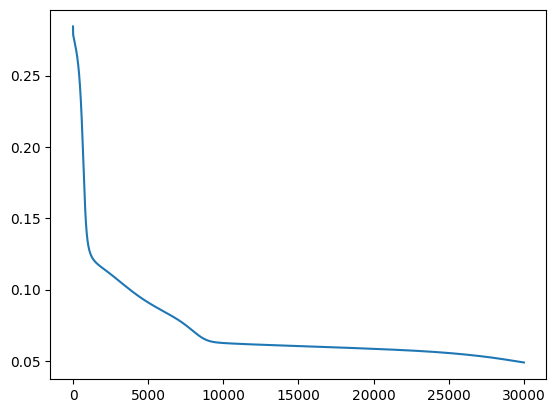

In [64]:
plt.plot(loss_history)

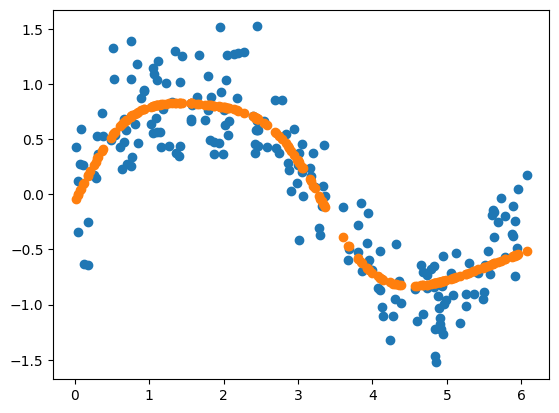

In [65]:
plt.scatter(x_samples, y_samples)
plt.scatter(x_samples, network_forward(x_samples, weight_matrices, bias_vectors, activation_functions))